In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,MaxPooling2D,Flatten,Dropout,BatchNormalization,GlobalAveragePooling2D,InputLayer
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
import time

In [79]:
# Data Import
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train,x_val,y_train,y_val=train_test_split(x_train,y_train,test_size=0.2,random_state=42)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)
class_names = [ 'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print("Number of classes:", len(class_names))

x_train shape: (48000, 28, 28)
y_train shape: (48000,)
x_val shape: (12000, 28, 28)
y_val shape: (12000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Number of classes: 10


In [80]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [81]:
x_val[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   2,   4,   0,   0,
        147, 125, 106, 113,  27,   0,   1,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   1,   1,   0,   0,   0,   3,   0,  27, 198,
         59,   0,   0,  16, 124,  40,   0,   2,   1,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   1,   2,   0,   2,   0, 173,  50,
          0,   0,   0,   0,   0, 137,   0,   0,   0,   1,   1,   0,   0,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   1,   0,   0,   3, 140,   0,
          0,   0,   0,  10,   0, 101,  45,   0,   4,   0,   0,   1,   1,
          0,   0],
       [  

In [82]:
for i in range(5):
  print(y_train[i+1])

3
5
8
6
9


In [83]:
# Reshaping and Normalizing the images

x_train=x_train.reshape(x_train.shape[0],x_train.shape[1],x_train.shape[2],1).astype('float32')/255
x_test=x_test.reshape(x_test.shape[0],x_test.shape[1],x_test.shape[2],1).astype('float32')/255
x_val=x_val.reshape(x_val.shape[0],x_val.shape[1],x_val.shape[2],1)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"x_val shape: {x_val.shape}")

x_train shape: (48000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)
x_val shape: (12000, 28, 28, 1)


In [8]:
#printing the first set of image array

for i in range(x_train[0].shape[0]):
  print(x_train[0][i])

[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]

In [84]:
# Converting target feature to ONE HOT Encoding

y_train=keras.utils.to_categorical(y_train,num_classes=len(class_names))
y_test=keras.utils.to_categorical(y_test,num_classes=len(class_names))
y_val=keras.utils.to_categorical(y_val,num_classes=len(class_names))

Q Why is normalization required for image data?
- Normalization is not only required for image data but all kinds of data so that whole data will be having One centre at 0 and std deviation of 1 and the Model Trained on that scaled/normalized data would be more generalized.Also Since Images are stored as Integers,High pixel values can cause exploding gradient problem during backpropagation and normalizing ensures that the loss curve is more sperical and not elongated.This allows the optimizer like Adam to find the global minima much faster.

Q Why do CNNs require reshaped image inputs?
- CNN requires reshaped images because of it's structure being only able to read 3D dimensional data having height,width and color channel of 3 for coloured images and 1 for grey scaled images.so that it can apply n filter's to create n feature maps all arranged along the depth creating a 3D feature map.
- Keras/Tensorflow expects a 4D tensor as input(BatchSize,height,width,channels),even there is only one image,it must be reshaped to include the batch size.

In [10]:
y_train.shape

(48000, 10)

In [11]:
y_train[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [12]:
# Building Shallow CNN Model

base_model=Sequential()
base_model.add(InputLayer(input_shape=(28,28,1)))
base_model.add(Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu'))
base_model.add(MaxPooling2D(pool_size=(2,2),strides=2))
base_model.add(Conv2D(filters=128,kernel_size=(3,3),padding='same',activation='relu'))
base_model.add(GlobalAveragePooling2D()),
base_model.add(Dense(units=256,activation='relu')),
base_model.add(Dense(units=len(class_names),activation='softmax'))

base_model.summary()

d:\D\adsw\DSA\hvc\hvenv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,090 (430.04 KB)

 Trainable params: 110,090 (430.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
#callbacks
model_checkpoint=keras.callbacks.ModelCheckpoint(
    filepath='best_shallow_cnn.keras',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='auto',
    save_freq='epoch',
    initial_value_threshold=0.01
)
early_stopping=keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    min_delta=0.01,
    patience=5,
    mode='auto',
    restore_best_weights=True,
    verbose=1
)


#Model Compilation
base_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_train=time.time()
history=base_model.fit(x_train,y_train,epochs=10,batch_size=128,callbacks=[model_checkpoint,early_stopping],validation_data=(x_val,y_val))
end_train=time.time()
training_time=(end_train-start_train)/60
print(f"Training time: {training_time} minutes")

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 71s 169ms/step - accuracy: 0.5200 - loss: 1.2776 - val_accuracy: 0.4770 - val_loss: 168.6891
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 170ms/step - accuracy: 0.6858 - loss: 0.8601 - val_accuracy: 0.4990 - val_loss: 149.4316
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 123s 279ms/step - accuracy: 0.7245 - loss: 0.7691 - val_accuracy: 0.4811 - val_loss: 238.7870
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 221ms/step - accuracy: 0.7467 - loss: 0.7038 - val_accuracy: 0.5529 - val_loss: 136.0227
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 71s 188ms/step - accuracy: 0.7638 - loss: 0.6581 - val_accuracy: 0.5498 - val_loss: 170.7470
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 69s 183ms/step - accuracy: 0.7797 - loss: 0.6145 - val_accuracy: 0.5383 - val_loss: 179.2148
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 67s 178ms/step - accuracy: 0.7896 - loss: 0.5817 - val_accuracy: 0.5850 - val_loss: 131.6640
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 181ms/step - accuracy: 0

In [45]:
sh_test_loss,sh_test_acc=base_model.evaluate(x_test,y_test)
print(f"Test Accuracy: {sh_test_acc}")
print(f"Test Loss: {sh_test_loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.8013 - loss: 0.5618
Test Accuracy: 0.8012999892234802
Test Loss: 0.561760663986206


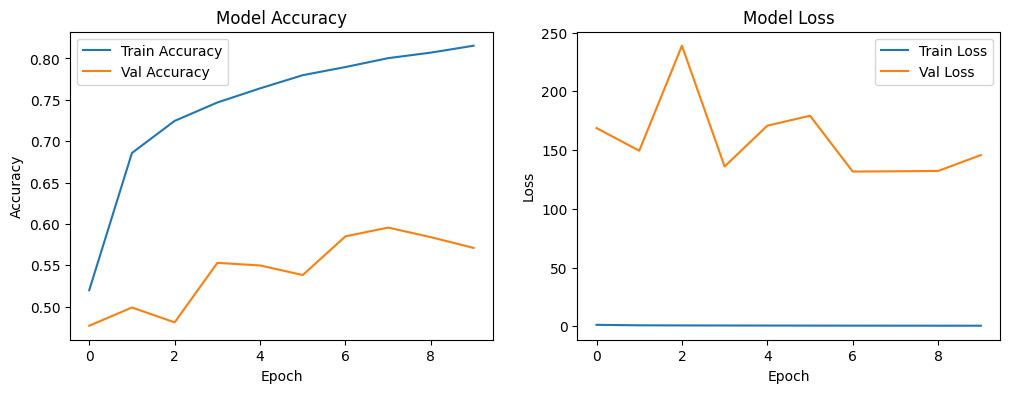

In [ ]:
# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()


In [32]:
print(f"last train accuracy : {history.history['accuracy'][-1]}")
print(f"last val accuracy : {history.history['val_accuracy'][-1]}")
print(f"differece in train and val accuracy : {history.history['accuracy'][-1]-history.history['val_accuracy'][-1]}")

last train accuracy : 0.8153333067893982
last val accuracy : 0.5709999799728394
differece in train and val accuracy : 0.24433332681655884


Q.What kind of patterns do you expect a shallow CNN to learn?


 - shallow Convolutional Neural Network (CNN) is typically designed to learn hierarchical features from image data. In the initial layers, a shallow CNN would generally learn basic and low-level patterns.
    - Edges and lines: Identifying different orientations of edges (horizontal, vertical, diagonal) and simple line segments.
    - Corners and blobs: Detecting corners, junctions, and simple circular or elliptical shapes.
    - Color and gradient transitions: Recognizing changes in color and intensity across the image.

Q. Did the model show signs of underfitting or overfitting?

- Since there is Huge difference of 0.24 between train_accuracy and val_accuracy model is kind of highly overfitting

In [ ]:
import keras_tuner as kt


class CNN_model(kt.HyperModel):
  def build(self,hp):
    model=Sequential()
    model.add(InputLayer(shape=(28,28,1)))

    reg_type=hp.Choice(f'reg_type',['l1','l2','l1_l2','None'])
    if reg_type=='l1':
      reg=keras.regularizers.L1(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l2':
      reg=keras.regularizers.L2(
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l1_l2':
      reg=keras.regularizers.L1L2(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log'),
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    else:
      reg=None


    model.add(Conv2D(64,3,padding='same',kernel_regularizer=reg))
    model.add(BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2,2),strides=2))
    model.add(tf.keras.layers.Dropout(0.2))
    model.add(Conv2D(128,3,padding='same',kernel_regularizer=reg))
    model.add(BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2,2),strides=2))
    model.add(Conv2D(256,3,padding='same',kernel_regularizer=reg))
    model.add(BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.Dropout(0.2))
    model.add(MaxPooling2D(pool_size=(2,2),strides=2))
    model.add(Conv2D(512,3,padding='same',kernel_regularizer=reg))
    model.add(BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2,2),strides=2))
    model.add(GlobalAveragePooling2D())
    model.add(Dense(512,activation='relu',kernel_regularizer=reg))
    model.add(Dense(512,activation='relu',kernel_regularizer=reg))
    model.add(Dense(len(class_names),activation='softmax'))


    learning_rate=hp.Float('learning_rate',min_value=1e-4,max_value=1e-1,sampling='log')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


  def fit(self,hp,model,x,y,*args,**kwargs):
    callbacks=kwargs.pop('callbacks',[])
    model_checkpoint=keras.callbacks.ModelCheckpoint(
        filepath='best_deep_cnn.keras',
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode='auto',
        save_freq='epoch',
        initial_value_threshold=0.01
    )
    early_stopping=keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        min_delta=0.1,
        patience=5,
        verbose=1,
        mode='auto',
        restore_best_weights=True,
        start_from_epoch=0
    )
    callbacks.append(model_checkpoint)
    callbacks.append(early_stopping)
    return model.fit(
        x=x,
        y=y,
        *args,
        batch_size=hp.Int('batch_size',min_value=16,max_value=512,step=16),
        epochs=hp.Int('epochs',min_value=5,max_value=25,step=5),
        verbose='auto',
        callbacks=[model_checkpoint,early_stopping],
        validation_split=hp.Float('validation_split',min_value=0.1,max_value=0.25,sampling='linear'),
        shuffle=hp.Boolean('shuffle'),
        **kwargs
    )


In [22]:
deep_model=CNN_model()
hp=kt.HyperParameters()
d_model=deep_model.build(hp)
d_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 3, 3, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 2,084,106 (7.95 MB)

 Trainable params: 2,082,186 (7.94 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [25]:
# !pip install tensorboard tensorflow-estimator -q

In [23]:
start_time=time.time()

tuner=kt.RandomSearch(
    hypermodel=CNN_model(),
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=3,
    overwrite=True,
    directory='tuned',
    project_name='fashion_mnist'
)
tuner.search(x_train,y_train,validation_data=(x_val,y_val))


hypermodel=CNN_model()
best_hp=tuner.get_best_hyperparameters()[0]
deep_model=hypermodel.build(best_hp)
deep_history=hypermodel.fit(best_hp,deep_model,x_train,y_train)


end_time=time.time()
total_time=(end_time-start_time)/60
print(f"total_time_taken: {total_time}")

Trial 5 Complete [01h 06m 10s]
val_accuracy: 0.4208611150582631

Best val_accuracy So Far: 0.8027500112851461
Total elapsed time: 08h 32m 16s
Epoch 1/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 942ms/step - accuracy: 0.6598 - loss: 1.6430
Epoch 1: val_accuracy improved from 0.01000 to 0.09879, saving model to best_deep_cnn.keras

Epoch 1: finished saving model to best_deep_cnn.keras
203/203 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.7766 - loss: 1.1039 - val_accuracy: 0.0988 - val_loss: 3.8819
Epoch 2/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 963ms/step - accuracy: 0.8657 - loss: 0.6557
Epoch 2: val_accuracy improved from 0.09879 to 0.44314, saving model to best_deep_cnn.keras

Epoch 2: finished saving model to best_deep_cnn.keras
203/203 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.8703 - loss: 0.6165 - val_accuracy: 0.4431 - val_loss: 1.6758
Epoch 3/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 984ms/step - accuracy: 0.8847 - loss: 0.5312
Epoch 3: val_accuracy improved from 0.44314 to 0.84418, saving m

In [47]:
# Plot training & validation accuracy and loss values
deep_test_loss,deep_test_acc=deep_model.evaluate(x_test,y_test)
print(f"Test Accuracy: {deep_test_acc}")
print(f"Test Loss: {deep_test_loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.8357 - loss: 0.6702
Test Accuracy: 0.8356999754905701
Test Loss: 0.6701691746711731


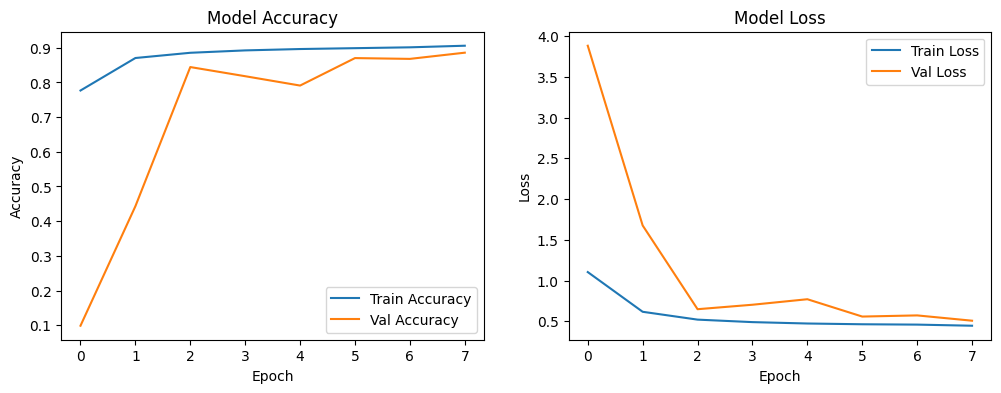

In [27]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(deep_history.history['accuracy'], label='Train Accuracy')
plt.plot(deep_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(deep_history.history['loss'], label='Train Loss')
plt.plot(deep_history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()


In [31]:
print(f"last train accuracy : {deep_history.history['accuracy'][-1]}")
print(f"last val accuracy : {deep_history.history['val_accuracy'][-1]}")
print(f"differece in train and val accuracy : {deep_history.history['accuracy'][-1]-deep_history.history['val_accuracy'][-1]}")

last train accuracy : 0.9056633114814758
last val accuracy : 0.885617733001709
differece in train and val accuracy : 0.020045578479766846


Q What additional patterns or representations might a deep CNN learn?

- In Initial Convolutional Layers,Model acts like basic edge detector.Model Identifies Vertical,horizontal and diagonal lines,simple color transition or intensity changes.
- In Mid Convolutional Layers,Model Starts Combining edges and starts creating geometric shapes like circles,square or specific curvatures
- In Deep Convolutional Layers,Model Develops Mathematical Representation of difference between different class of objects


Q Did the deeper model improve performance meaningfully?
- Yes,the Deeper Model with Hyperparameter Tuning has Improved very much and it is not Overfitted,though due to hyperparameter tuning on CPU it took 540 minutes to tune and fit the model,there is only difference of 0.02 between Train and Val accuracy 

In [41]:
shallow_conv_count=0
shallow_trainable_param=0
for l in base_model.layers:
    if type(l).__name__=='Conv2D':
        shallow_conv_count+=1
    shallow_trainable_param+=l.count_params()
print(shallow_conv_count)
print(shallow_trainable_param)

2
110090


In [42]:
deep_conv_count=0
deep_trainable_param=0
for l in deep_model.layers:
    if type(l).__name__=='Conv2D':
        deep_conv_count+=1
    deep_trainable_param+=l.count_params()
print(deep_conv_count)
print(deep_trainable_param)

4
2084106


In [54]:
print(f"Shallow convolution Layer Count : {shallow_conv_count}")
print(f"Shallow total Parameters : {shallow_trainable_param}")
shallow_last_train_acc=history.history['accuracy'][-1]
print(f"Shallow Train Accuracy : {shallow_last_train_acc}")
shallow_last_val_acc=history.history['val_accuracy'][-1]
print(f"Shallow Validation Accuracy : {shallow_last_val_acc}")
print(f"Shallow Test Accuracy{sh_test_acc}")
print(f"Shallow Training Time : {training_time} minutes")

Shallow convolution Layer Count : 2
Shallow total Parameters : 110090
Shallow Train Accuracy : 0.8153333067893982
Shallow Validation Accuracy : 0.5709999799728394
Shallow Test Accuracy0.8012999892234802
Shallow Training Time : 13.538584013779959 minutes


In [55]:
print(f"Deep convolution Layer Count : {deep_conv_count}")
print(f"Deep total Parameters : {deep_trainable_param}")
deep_last_train_acc=deep_history.history['accuracy'][-1]
print(f"Deep Train Accuracy : {deep_last_train_acc}")
deep_last_val_acc=deep_history.history['val_accuracy'][-1]
print(f"Deep Validation Accuracy : {deep_last_val_acc}")
print(f"Deep Test Accuracy : {deep_test_acc}")
print(f"Deep Training time : {total_time} minutes")

Deep convolution Layer Count : 4
Deep total Parameters : 2084106
Deep Train Accuracy : 0.9056633114814758
Deep Validation Accuracy : 0.885617733001709
Deep Test Accuracy : 0.8356999754905701
Deep Training time : 540.5805192828178 minutes


In [67]:
import pandas as pd

comp_table=pd.DataFrame({'metrics':['Number_of_Conv_Layers',
                         'Total_Parameters',
                         'Training_Accuracy',
                         'Validation_Accuracy',
                         'Test_Accuracy',
                         'Is_Overfitted',
                         'Training_Time(Minutes)'],
             'Shallow_CNN':[shallow_conv_count,
                            shallow_trainable_param,
                            shallow_last_train_acc,
                            shallow_last_val_acc,
                            sh_test_acc,
                            'Yes' if abs(shallow_last_train_acc-shallow_last_val_acc)>.05 else 'No',
                            training_time],
             'Deep_CNN':[deep_conv_count,
                         deep_trainable_param,
                         deep_last_train_acc,
                         deep_last_val_acc,
                         deep_test_acc,
                         'Yes' if abs(deep_last_train_acc-deep_last_val_acc)>.05 else 'No',
                         total_time]
            } )
print(f"Comparison Table :\n {comp_table}")
from IPython.display import Markdown, display
display(Markdown(f"""Q Which model performed better overall?

Q Did the deep CNN justify its added complexity?

Q Which model generalized better?
- Answer for ALL three above Questions
- Since Shallow CNN model is HIgly Overfitted having difference of more than 0.05 between Training Accuracy and Validation Accuracy,it is clearly seen that Deep_CNN model has good over all performance having  
    - {round(deep_last_train_acc-shallow_last_train_acc,3)} training accuracy,
    - {round(deep_last_val_acc-shallow_last_val_acc,2)}  Validation Accuracy  
    - {round(sh_test_acc-deep_test_acc,3)} test Accuracy 

higher than Shallow CNN.Also it Justifies It's added Complexity and is more Generalized Because of the Above mentioned points 


Q What trade-off did you observe between simplicity and performance?

- Shallow CNN Model is Simple,takes very less 13 minutes on CPU time to train but difference between training and validation accuracy is very high,whereas Deep CNN model is complex,hyperparameterised learning rate,regularization value and choice of regularization(s) and takes more than 9 hours on CPU but difference between it's Training Accuracy and validation accuracy is just 0.02 which makes it more generalised Model"""))

Comparison Table :
                   metrics Shallow_CNN    Deep_CNN
0   Number_of_Conv_Layers           2           4
1        Total_Parameters      110090     2084106
2       Training_Accuracy    0.815333    0.905663
3     Validation_Accuracy       0.571    0.885618
4           Test_Accuracy      0.8013      0.8357
5           Is_Overfitted         Yes          No
6  Training_Time(Minutes)   13.538584  540.580519


Q Which model performed better overall?

Q Did the deep CNN justify its added complexity?

Q Which model generalized better?
- Answer for ALL three above Questions
- Since Shallow CNN model is HIgly Overfitted having difference of more than 0.05 between Training Accuracy and Validation Accuracy,it is clearly seen that Deep_CNN model has good over all performance having  
    - 0.09 training accuracy,
    - 0.31  Validation Accuracy  
    - -0.034 test Accuracy 

higher than Shallow CNN.Also it Justifies It's added Complexity and is more Generalized Because of the Above mentioned points 


Q What trade-off did you observe between simplicity and performance?

- Shallow CNN Model is Simple,takes very less 13 minutes on CPU time to train but difference between training and validation accuracy is very high,whereas Deep CNN model is complex,hyperparameterised learning rate,regularization value and choice of regularization(s) and takes more than 9 hours on CPU but difference between it's Training Accuracy and validation accuracy is just 0.02 which makes it more generalised Model

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
base_pred=np.argmax(base_model.predict(x_test),axis=1)
deep_pred=np.argmax(deep_model.predict(x_test),axis=1)

y_true=np.argmax(y_test,axis=1)
y_true

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step


array([9, 2, 1, ..., 8, 1, 5], shape=(10000,))

In [76]:

def plot_samples(model_name,y_true,y_pred,image,class_names):
    correct_index=np.where(y_pred==y_true)[0]
    incorrect_index=np.where(y_pred!=y_true)[0]

    fig,axes=plt.subplots(2,5,figsize=(20,15))
    fig.suptitle(f"{model_name} - correct vs Incorrect")

    for i in range(5):
        idx=correct_index[i]
        axes[0,i].imshow(image[idx].reshape(28,28),cmap='grey')
        axes[0, i].set_title(f"A: {class_names[y_true[idx]]}\nP: {class_names[y_pred[idx]]}", color='green')
        axes[0, i].axis('off')

    for i in range(5):
        idx = incorrect_index[i]
        axes[1, i].imshow(image[idx].reshape(28,28), cmap='gray')
        axes[1, i].set_title(f"A: {class_names[y_true[idx]]}\nP: {class_names[y_pred[idx]]}", color='red')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

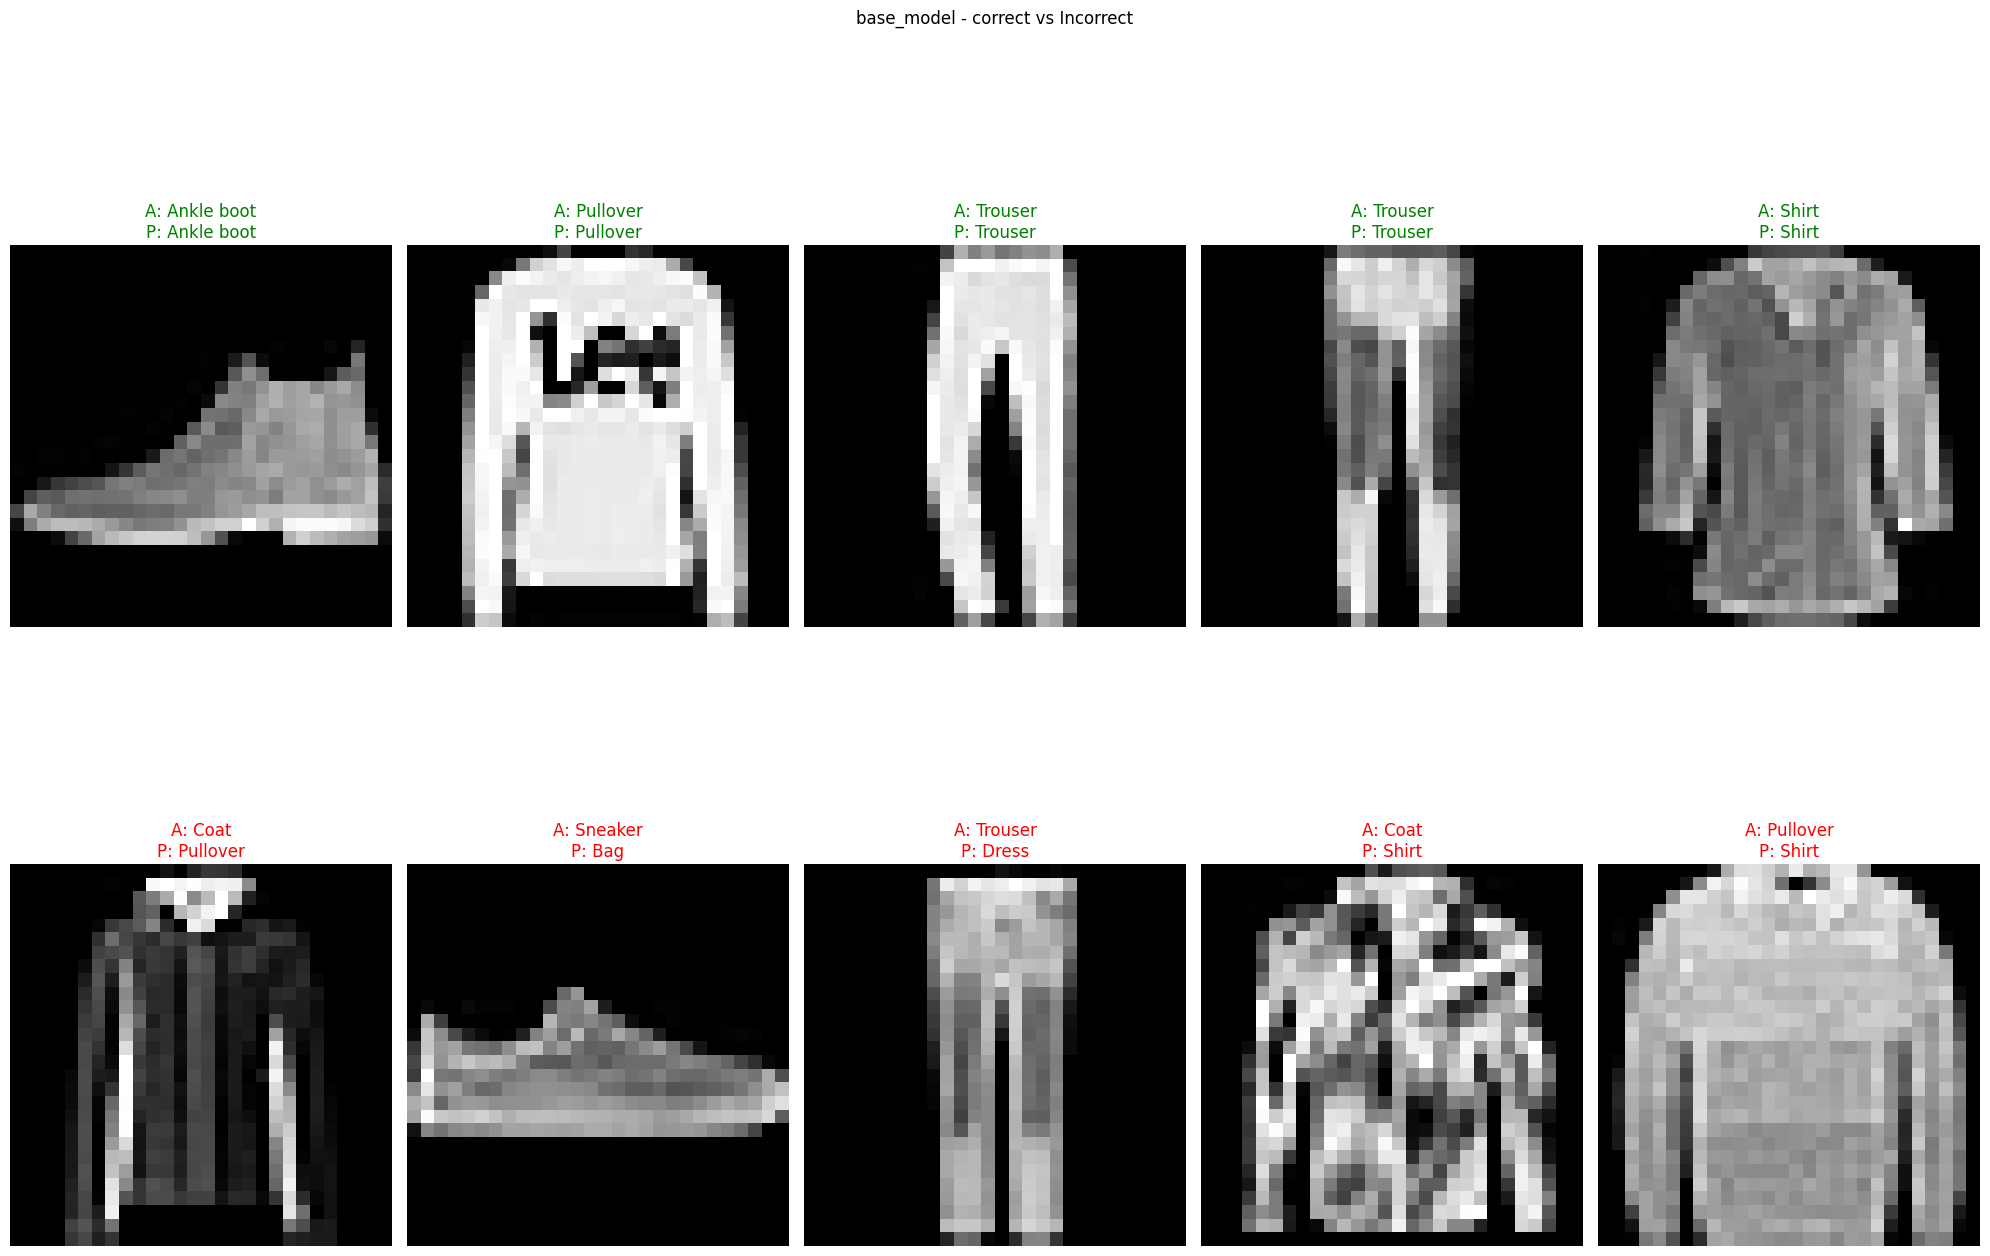

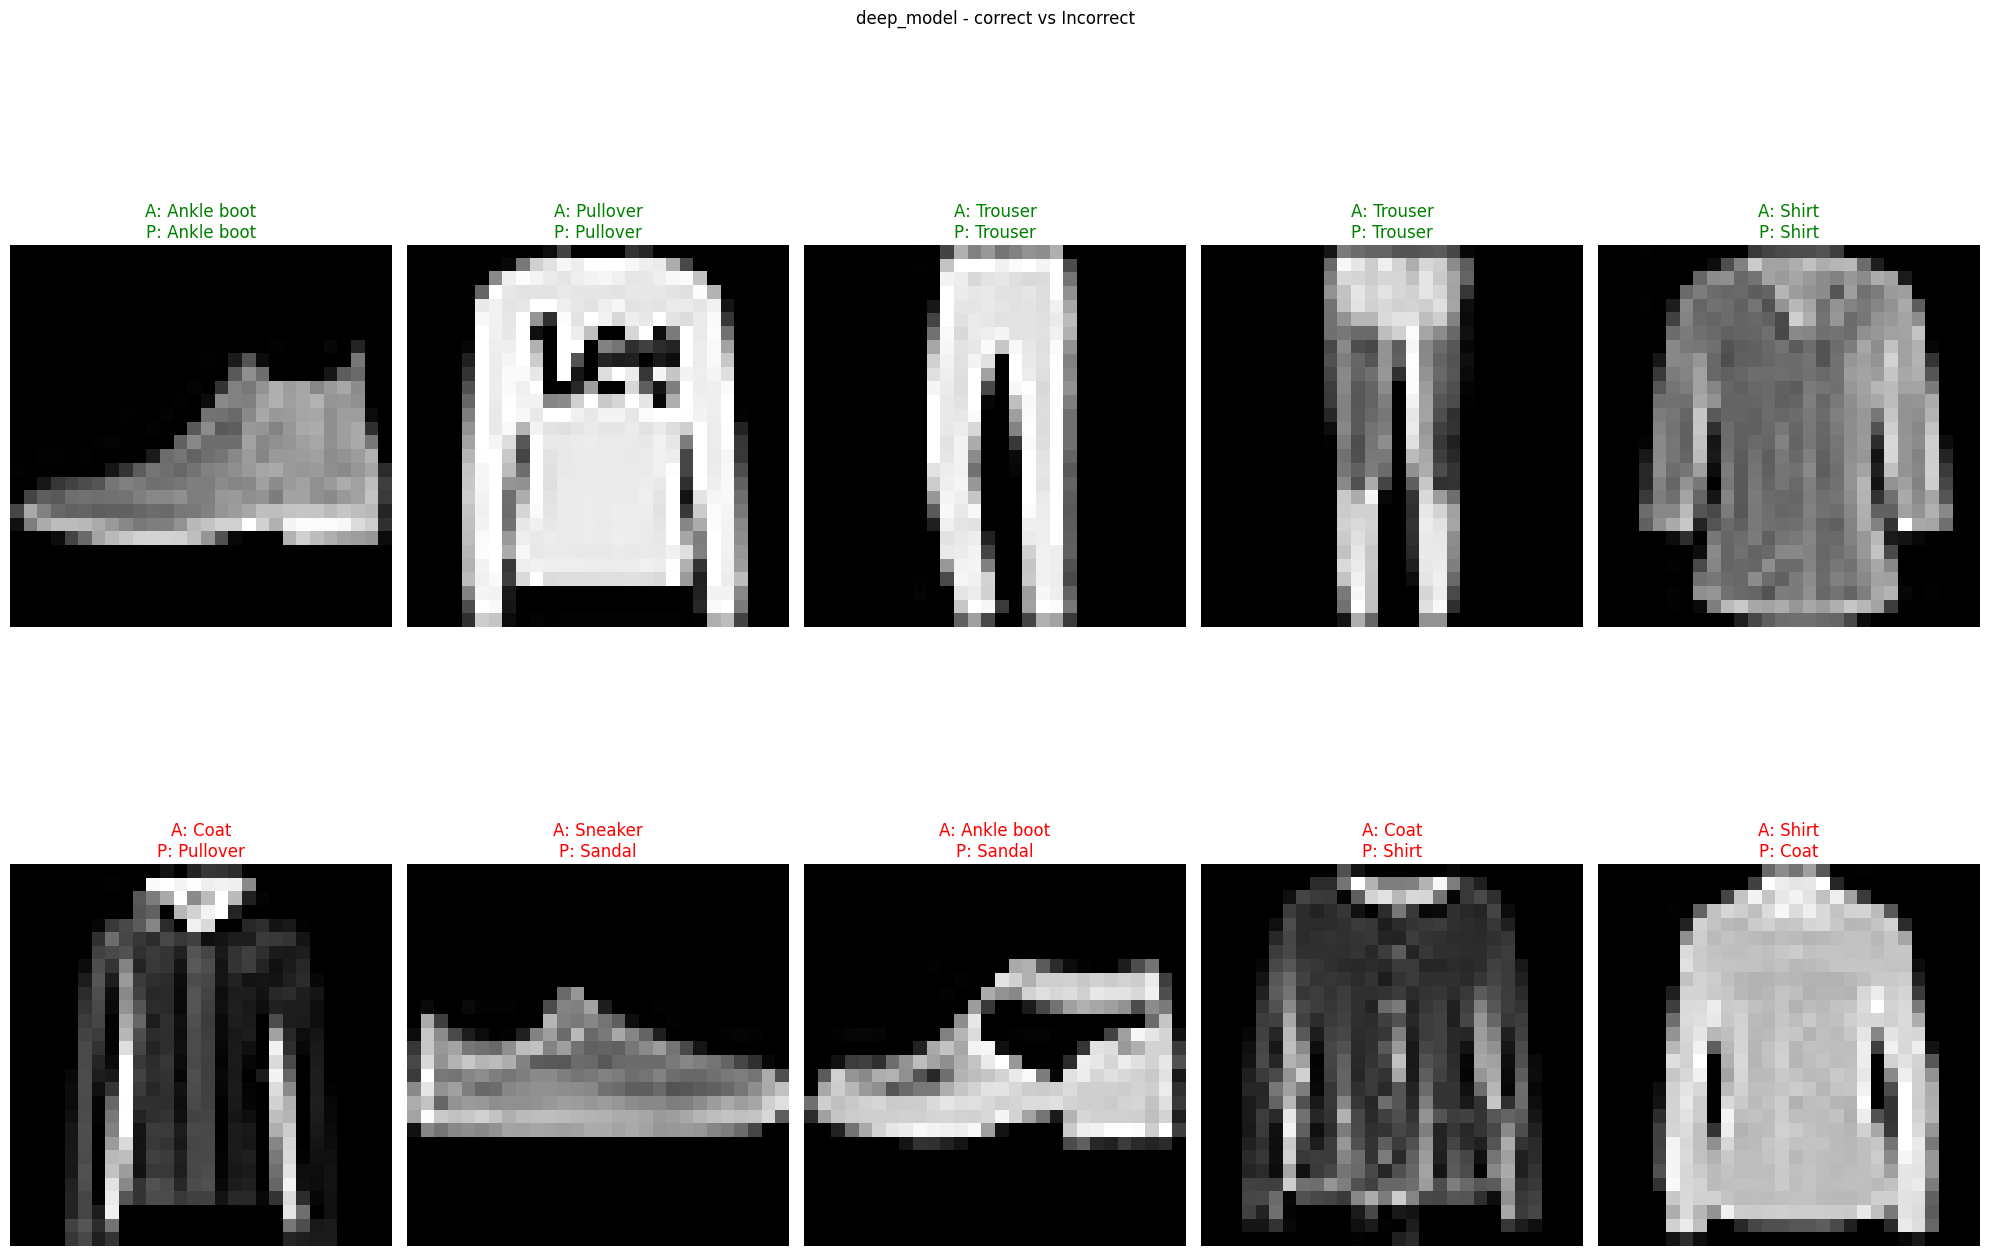

In [ ]:
(_, _), (x_test_viz, _) = fashion_mnist.load_data()

plot_samples(model_name='base_model',y_true=y_true,y_pred=base_pred,image=x_test_viz,class_names=class_names)
plot_samples(model_name='deep_model',y_true=y_true,y_pred=deep_pred,image=x_test_viz,class_names=class_names)

<Figure size 1000x800 with 0 Axes>

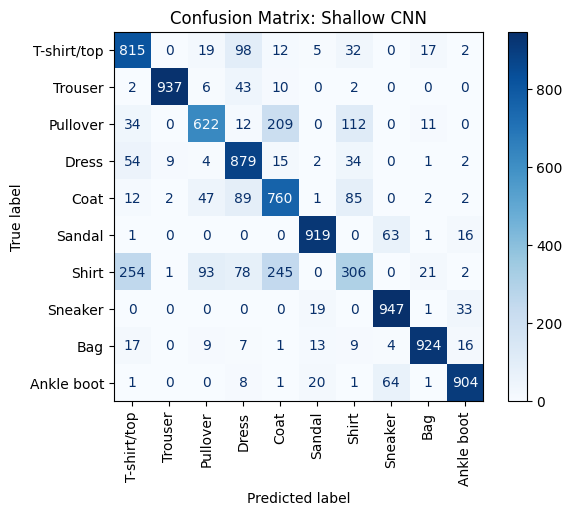

<Figure size 1000x800 with 0 Axes>

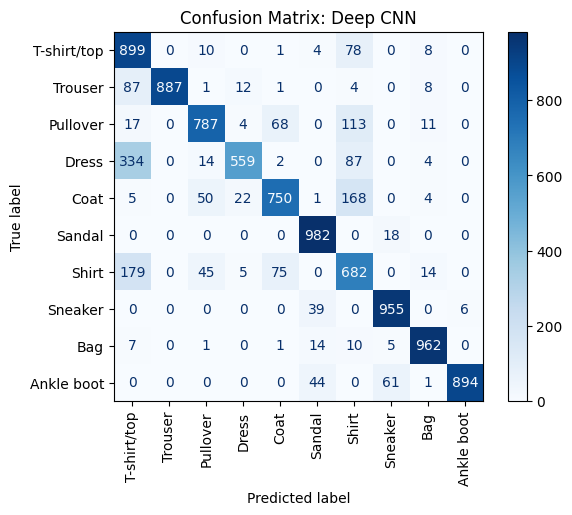

In [87]:
def plot_cm(y_true, y_pred, model_name, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(xticks_rotation='vertical', cmap='Blues')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

plot_cm(y_true, base_pred, "Shallow CNN", class_names)
plot_cm(y_true, deep_pred, "Deep CNN", class_names)

In [89]:
print(f"Shallow CNN Classifiaction_report : \n{classification_report(y_true,base_pred,target_names=class_names)}")
print(f"Deep CNN Classifiaction_report : \n{classification_report(y_true,deep_pred,target_names=class_names)}")

Shallow CNN Classifiaction_report : 
              precision    recall  f1-score   support

 T-shirt/top       0.68      0.81      0.74      1000
     Trouser       0.99      0.94      0.96      1000
    Pullover       0.78      0.62      0.69      1000
       Dress       0.72      0.88      0.79      1000
        Coat       0.61      0.76      0.67      1000
      Sandal       0.94      0.92      0.93      1000
       Shirt       0.53      0.31      0.39      1000
     Sneaker       0.88      0.95      0.91      1000
         Bag       0.94      0.92      0.93      1000
  Ankle boot       0.93      0.90      0.91      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.79     10000
weighted avg       0.80      0.80      0.79     10000

Deep CNN Classifiaction_report : 
              precision    recall  f1-score   support

 T-shirt/top       0.59      0.90      0.71      1000
     Trouser       1.00      0.89      0.94      1000
    Pul

Q Which classes were easiest to classify?
- for Shallow CNN
    - Trouser,Sandal,Sneaker,Bag,Ankle Boot
- for Deep CNN
    - Trouser,Pullover,Sandal,Sneaker,Bag,Ankle Boot

Q Which classes were most commonly confused?
- for shallow CNN
    - T-shirt/top,Pullover,Dress,Coat,Shirt
- for Deep CNN
    - T-shirt/top,Dress,Coat,Shirt

Q Did the deep CNN reduce confusion between similar-looking classes?
- Pullover,Coat,Shirt

# Final Conclusion
Through All the training and testing It is clearly seen that Deep CNN model has higher Accuracy along Training,Validation and test data.Deep CNN has very less Variance between training and Validation Data while Shallow CNN has very High Variance between training and validation Data which clearly Indicates that Shallow CNN was overfitted and memorizing the data.Deep CNN was More Genarlised due to HYperparameter tuning,Extra Convolutional layers which not only helped in extracting shapes,lines,curves and colour transitions and directly  representing them mathematically but also helped in combining those extracted features.Extra layers like BatchNormalization,Dropout layers have been also used in Deep CNN Model making more generalized.I would Higly Recommend to use the Deep CNN Model as it is more generalised as it has tuned Regularization parameter  with optimizer having tuned learning Rate which were not present in shallow CNN.

Efficiency vs. Performance:

though Shallow CNN has less layers with No tuned regularization and  learning rate,it took only 13.5 minutes on CPU to get trained while Deep CNN took 9 hours on CPU to get trained which makes Deep CNN Computationally expensive and time consuming with just a difference of 3% in test accuracy which makes the Shallow CNN more efficient

But again if wee look at the classifiaction report,Shallow CNN get confused with classes like shirt,coat,pullovers while Deep CNN more efficiently predict these classes correctly which makes the Deep CNN more accurate on Predictions

Key Learnings:

Therefore,we can see that More convolutional layers with Batchnormalization and Dropouts with tuning the hyperparameters like learning rate,choice of regularization and it's value makes the Model to avoid memorizing the data and made it  More generalized which helps in not only extracting features but also helps in combining those features and representing them mathematically and accurately but that generalization comes with cost of time and computation.we can also observe from confusion matrix CNN struggles with  data having semantic similarity,thus data quality and class are as much important as Architechutre of the CNN model